# DESAFIO 07 — Cancelamento de Reservas de Hotel

**Disciplina:** IA - Classificadores  
**Grupo:** 7 | **Domínio:** Hotelaria  
**Tipo:** Classificação Binária  
**Dataset:** [jessemostipak/hotel-booking-demand](https://www.kaggle.com/datasets/jessemostipak/hotel-booking-demand)  
**Data de Entrega:** 19-04-2026  

---

## Objetivo

Prever se uma reserva de hotel será **cancelada** (`is_canceled = 1`) ou **mantida** (`is_canceled = 0`).  
Cancelamentos de última hora causam prejuízos significativos. Prever quais reservas têm maior probabilidade de cancelamento permite:
- Overbooking estratégico
- Ações de retenção proativas
- Otimização de receita

---

## Estrutura do Notebook

| Etapa | Descrição |
|-------|-----------|
| **Etapa 1** | Análise Exploratória (EDA) |
| **Etapa 2** | Pré-processamento |
| **Etapa 3** | Comparação de Classificadores |
| **Etapa 4** | Análise Comparativa e Conclusões |

## Bloco 1 — Importação e Configuração do Ambiente

In [1]:
# === BIBLIOTECAS PRINCIPAIS ===
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Pré-processamento
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler, LabelEncoder, OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer

# Modelos
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

# Métricas
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, roc_curve, confusion_matrix, ConfusionMatrixDisplay,
    classification_report
)

# Configurações visuais
sns.set_theme(style='whitegrid', palette='muted', font_scale=1.05)
plt.rcParams['figure.dpi'] = 110
plt.rcParams['axes.titlesize'] = 13
plt.rcParams['axes.labelsize'] = 11

RANDOM_STATE = 42
print("✅ Ambiente configurado com sucesso!")

✅ Ambiente configurado com sucesso!


## Bloco 2 — Carregamento do Dataset

> **Download via Kaggle CLI:**
> ```bash
> kaggle datasets download -d jessemostipak/hotel-booking-demand
> unzip hotel-booking-demand.zip
> ```
> Ou faça o download direto em: https://www.kaggle.com/datasets/jessemostipak/hotel-booking-demand

In [2]:
!kaggle datasets download -d jessemostipak/hotel-booking-demand
!unzip hotel-booking-demand.zip


Dataset URL: https://www.kaggle.com/datasets/jessemostipak/hotel-booking-demand
License(s): Attribution 4.0 International (CC BY 4.0)
100% 1.25M/1.25M [00:00<00:00, 21.9MB/s]

Archive:  hotel-booking-demand.zip
  inflating: hotel_bookings.csv      


In [3]:
# === CARREGAMENTO DO DATASET ===
# Ajuste o caminho conforme necessário
df_full = pd.read_csv('hotel_bookings.csv')

print(f"Dataset completo: {df_full.shape[0]:,} linhas × {df_full.shape[1]} colunas")
print(f"Variável alvo — distribuição completa:")
print(df_full['is_canceled'].value_counts())

Dataset completo: 119,390 linhas × 32 colunas
Variável alvo — distribuição completa:
is_canceled
0    75166
1    44224
Name: count, dtype: int64


In [4]:
# === AMOSTRAGEM: 10000 REGISTROS ===
# Amostragem estratificada para manter a proporção de cancelamentos
df = df_full.groupby('is_canceled', group_keys=False).apply(
    lambda x: x.sample(frac=10000/len(df_full), random_state=RANDOM_STATE)
).reset_index(drop=True)

# Garantir exatamente 10000 amostras
df = df.sample(n=10000, random_state=RANDOM_STATE).reset_index(drop=True)

print(f"Amostra utilizada: {df.shape[0]:,} linhas × {df.shape[1]} colunas")
print(f"\nDistribuição da variável alvo (amostra):")
print(df['is_canceled'].value_counts())
print(f"\nTaxa de cancelamento na amostra: {df['is_canceled'].mean():.2%}")

Amostra utilizada: 10,000 linhas × 32 colunas

Distribuição da variável alvo (amostra):
is_canceled
0    6296
1    3704
Name: count, dtype: int64

Taxa de cancelamento na amostra: 37.04%


In [5]:
# === AMOSTRAGEM DO DATAFRAME ===
print("=== PRIMEIRAS 5 LINHAS ===")
df.head()

=== PRIMEIRAS 5 LINHAS ===


,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
0,Resort Hotel,0,53,2017,April,17,28,1,2,2,...,No Deposit,240.0,NaN,0,Transient,147.00,0,2,Check-Out,2017-05-01
1,City Hotel,0,45,2016,November,46,7,1,2,2,...,No Deposit,83.0,NaN,0,Transient,147.60,0,0,Check-Out,2016-11-10
2,City Hotel,0,103,2017,April,18,30,2,2,2,...,No Deposit,28.0,NaN,0,Transient,85.00,0,0,Check-Out,2017-05-04
3,City Hotel,0,21,2016,February,8,17,0,3,2,...,No Deposit,9.0,NaN,0,Transient,79.00,0,1,Check-Out,2016-02-20
4,City Hotel,0,128,2016,July,29,11,1,2,2,...,No Deposit,9.0,NaN,0,Transient-Party,97.43,0,1,Check-Out,2016-07-14


In [7]:
# === INFORMAÇÕES GERAIS ===
print(f"Shape: {df.shape}")
print(f"\nTipos de dados:")
print(df.dtypes.value_counts())
print(f"\nValores nulos por coluna (top 10):")
nulls = df.isnull().sum()
print(nulls[nulls > 0].sort_values(ascending=False).head(10))

Shape: (10000, 32)

Tipos de dados:
int64      16
object     12
float64     4
Name: count, dtype: int64

Valores nulos por coluna (top 10):
company    9441
agent      1358
country      32
dtype: int64


In [8]:
# === ESTATÍSTICAS DESCRITIVAS ===
df.describe().round(2)

,is_canceled,lead_time,arrival_date_year,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,children,babies,is_repeated_guest,previous_cancellations,previous_bookings_not_canceled,booking_changes,agent,company,days_in_waiting_list,adr,required_car_parking_spaces,total_of_special_requests
count,10000.00,10000.00,10000.00,10000.00,10000.00,10000.00,10000.00,10000.00,10000.00,10000.00,10000.00,10000.00,10000.00,10000.00,8642.00,559.00,10000.00,10000.00,10000.00,10000.00
mean,0.37,103.23,2016.14,27.17,15.82,0.91,2.49,1.86,0.11,0.01,0.03,0.09,0.14,0.22,86.46,180.48,2.55,102.82,0.06,0.56
std,0.48,106.31,0.71,13.55,8.78,0.97,1.86,0.58,0.40,0.09,0.17,0.84,1.54,0.62,110.11,134.73,18.06,71.72,0.24,0.79
min,0.00,0.00,2015.00,1.00,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,1.00,6.00,0.00,0.00,0.00,0.00
25%,0.00,18.00,2016.00,16.00,8.00,0.00,1.00,2.00,0.00,0.00,0.00,0.00,0.00,0.00,9.00,47.00,0.00,69.56,0.00,0.00
50%,0.00,69.00,2016.00,28.00,16.00,1.00,2.00,2.00,0.00,0.00,0.00,0.00,0.00,0.00,14.00,169.00,0.00,95.00,0.00,0.00
75%,1.00,159.00,2017.00,38.00,23.00,2.00,3.00,2.00,0.00,0.00,0.00,0.00,0.00,0.00,229.00,248.50,0.00,126.00,0.00,1.00
max,1.00,622.00,2017.00,53.00,31.00,10.00,25.00,26.00,3.00,1.00,1.00,26.00,64.00,13.00,531.00,525.00,391.00,5400.00,3.00,5.00


---

# ETAPA 1 | Análise Exploratória (EDA)

## Bloco 3 — Taxa de Cancelamento Geral

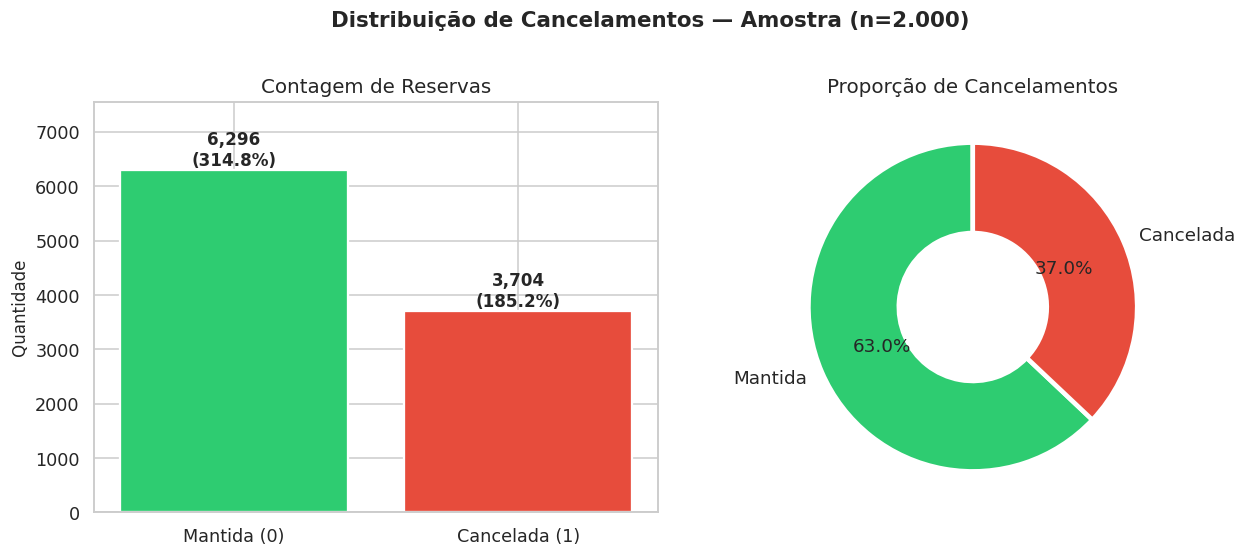


Taxa de cancelamento: 37.04%


In [9]:
# === TAXA DE CANCELAMENTO GERAL ===
cancel_counts = df['is_canceled'].value_counts()
cancel_pct = df['is_canceled'].value_counts(normalize=True) * 100

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle('Distribuição de Cancelamentos — Amostra (n=10.000)', fontsize=14, fontweight='bold', y=1.01)

# Gráfico 1: Barras
colors = ['#2ecc71', '#e74c3c']
bars = axes[0].bar(['Mantida (0)', 'Cancelada (1)'], cancel_counts.values, color=colors, edgecolor='white', linewidth=1.5)
axes[0].set_title('Contagem de Reservas')
axes[0].set_ylabel('Quantidade')
for bar, val in zip(bars, cancel_counts.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 10,
                 f'{val:,}\n({val/10000*100:.1f}%)', ha='center', va='bottom', fontsize=11, fontweight='bold')
axes[0].set_ylim(0, max(cancel_counts.values) * 1.2)

# Gráfico 2: Pizza
wedge_props = dict(width=0.55, edgecolor='white', linewidth=3)
axes[1].pie(cancel_counts.values, labels=['Mantida', 'Cancelada'],
            autopct='%1.1f%%', colors=colors, startangle=90,
            wedgeprops=wedge_props, textprops={'fontsize': 12})
axes[1].set_title('Proporção de Cancelamentos')

plt.tight_layout()
plt.savefig('01_taxa_cancelamento.png', bbox_inches='tight', dpi=120)
plt.show()
print(f"\nTaxa de cancelamento: {cancel_pct[1]:.2f}%")

## Bloco 4 — Padrões por Tipo de Hotel

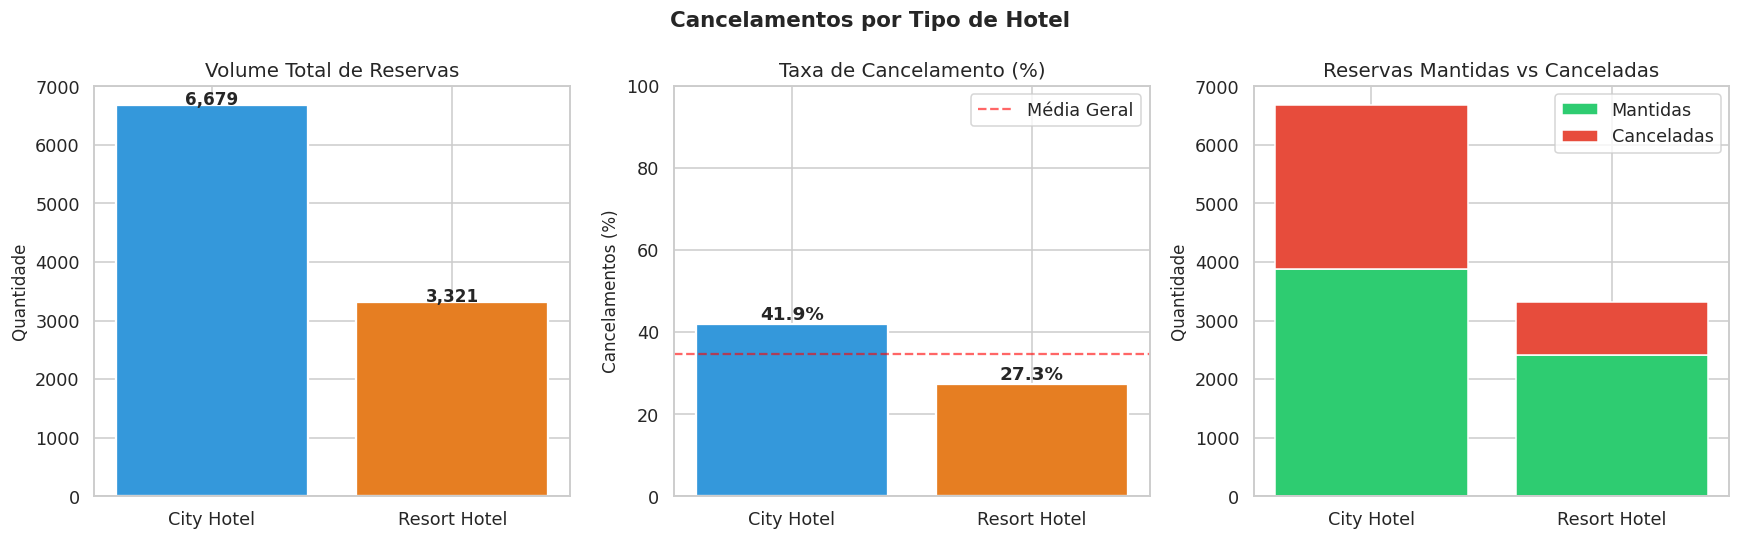

       hotel  total  cancelados  taxa_cancelamento_pct
  City Hotel   6679        2798              41.892499
Resort Hotel   3321         906              27.280939


In [10]:
# === CANCELAMENTO POR TIPO DE HOTEL ===
hotel_cancel = df.groupby('hotel')['is_canceled'].agg(['sum', 'count', 'mean']).reset_index()
hotel_cancel.columns = ['hotel', 'cancelados', 'total', 'taxa_cancelamento']
hotel_cancel['taxa_cancelamento_pct'] = hotel_cancel['taxa_cancelamento'] * 100

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('Cancelamentos por Tipo de Hotel', fontsize=14, fontweight='bold')

hotel_colors = {'City Hotel': '#3498db', 'Resort Hotel': '#e67e22'}
hcolors = [hotel_colors.get(h, '#95a5a6') for h in hotel_cancel['hotel']]

# Volume total por hotel
axes[0].bar(hotel_cancel['hotel'], hotel_cancel['total'], color=hcolors, edgecolor='white', linewidth=1.5)
axes[0].set_title('Volume Total de Reservas')
axes[0].set_ylabel('Quantidade')
for i, (_, row) in enumerate(hotel_cancel.iterrows()):
    axes[0].text(i, row['total'] + 5, f"{int(row['total']):,}", ha='center', fontsize=11, fontweight='bold')

# Taxa de cancelamento por hotel
bars = axes[1].bar(hotel_cancel['hotel'], hotel_cancel['taxa_cancelamento_pct'], color=hcolors, edgecolor='white', linewidth=1.5)
axes[1].set_title('Taxa de Cancelamento (%)')
axes[1].set_ylabel('Cancelamentos (%)')
axes[1].set_ylim(0, 100)
axes[1].axhline(y=hotel_cancel['taxa_cancelamento_pct'].mean(), color='red', linestyle='--', alpha=0.6, label='Média Geral')
axes[1].legend()
for bar, val in zip(bars, hotel_cancel['taxa_cancelamento_pct']):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
                 f'{val:.1f}%', ha='center', fontsize=12, fontweight='bold')

# Cancelados vs Mantidos por hotel (stacked)
hotel_cancel['mantidos'] = hotel_cancel['total'] - hotel_cancel['cancelados']
axes[2].bar(hotel_cancel['hotel'], hotel_cancel['mantidos'], label='Mantidas', color='#2ecc71', edgecolor='white')
axes[2].bar(hotel_cancel['hotel'], hotel_cancel['cancelados'], bottom=hotel_cancel['mantidos'],
            label='Canceladas', color='#e74c3c', edgecolor='white')
axes[2].set_title('Reservas Mantidas vs Canceladas')
axes[2].set_ylabel('Quantidade')
axes[2].legend()

plt.tight_layout()
plt.savefig('02_cancelamento_hotel.png', bbox_inches='tight', dpi=120)
plt.show()
print(hotel_cancel[['hotel', 'total', 'cancelados', 'taxa_cancelamento_pct']].to_string(index=False))

## Bloco 5 — Lead Time: Análise do Principal Preditor

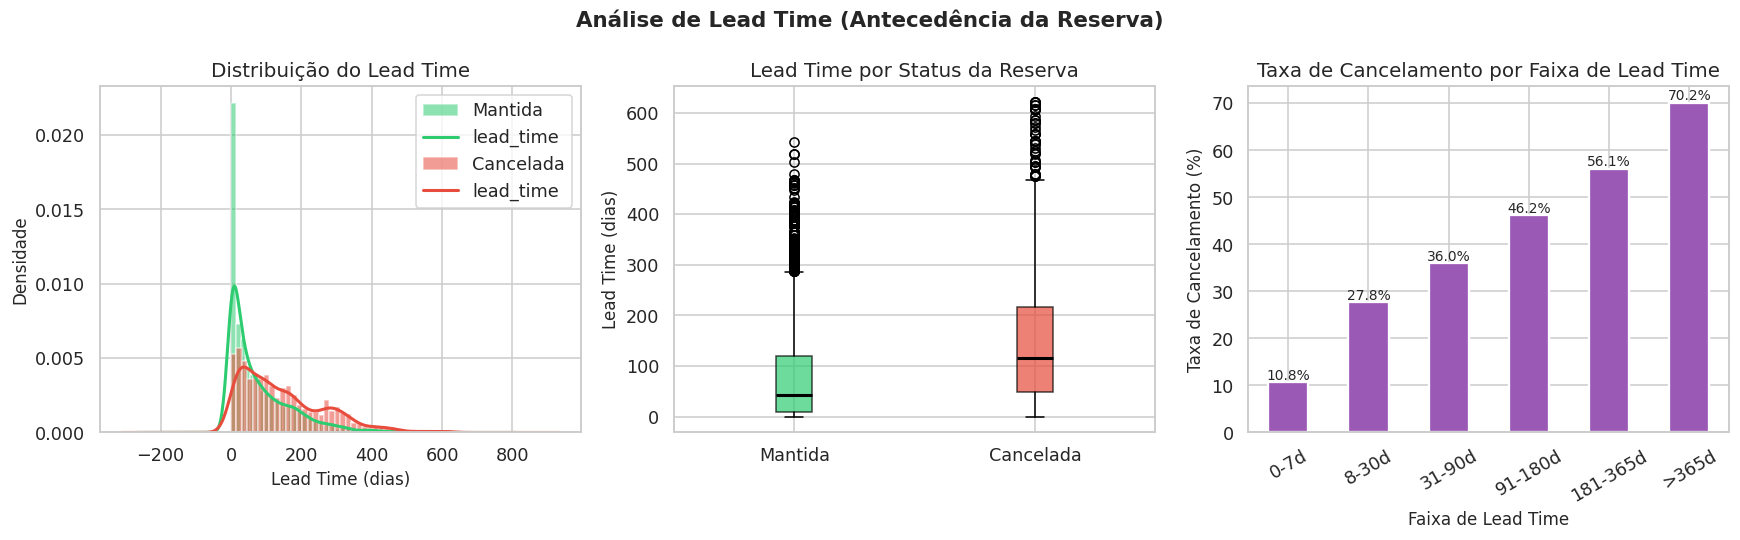

=== LEAD TIME — ESTATÍSTICAS DESCRITIVAS ===
              count    mean     std  min    25%    50%    75%    max
is_canceled                                                         
0            6296.0   78.00   88.90  0.0   8.75   43.0  120.0  542.0
1            3704.0  146.12  119.01  0.0  48.00  115.0  217.0  622.0


In [11]:
# === ANÁLISE DO LEAD TIME ===
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('Análise de Lead Time (Antecedência da Reserva)', fontsize=14, fontweight='bold')

# Histograma com KDE por status
for status, label, color in [(0, 'Mantida', '#2ecc71'), (1, 'Cancelada', '#e74c3c')]:
    subset = df[df['is_canceled'] == status]['lead_time']
    axes[0].hist(subset, bins=40, alpha=0.55, color=color, label=label, density=True)
    subset.plot.kde(ax=axes[0], color=color, linewidth=2)
axes[0].set_title('Distribuição do Lead Time')
axes[0].set_xlabel('Lead Time (dias)')
axes[0].set_ylabel('Densidade')
axes[0].legend()

# Boxplot
df_plot = df[['lead_time', 'is_canceled']].copy()
df_plot['Status'] = df_plot['is_canceled'].map({0: 'Mantida', 1: 'Cancelada'})
groups = [df_plot[df_plot['Status'] == s]['lead_time'].values for s in ['Mantida', 'Cancelada']]
bp = axes[1].boxplot(groups, labels=['Mantida', 'Cancelada'], patch_artist=True,
                     medianprops={'color': 'black', 'linewidth': 2})
for patch, color in zip(bp['boxes'], ['#2ecc71', '#e74c3c']):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)
axes[1].set_title('Lead Time por Status da Reserva')
axes[1].set_ylabel('Lead Time (dias)')

# Lead time por faixas
df['lead_time_faixa'] = pd.cut(df['lead_time'], bins=[0, 7, 30, 90, 180, 365, 999],
                                labels=['0-7d', '8-30d', '31-90d', '91-180d', '181-365d', '>365d'])
cancel_by_faixa = df.groupby('lead_time_faixa')['is_canceled'].mean() * 100
cancel_by_faixa.plot(kind='bar', ax=axes[2], color='#9b59b6', edgecolor='white', linewidth=1.5)
axes[2].set_title('Taxa de Cancelamento por Faixa de Lead Time')
axes[2].set_xlabel('Faixa de Lead Time')
axes[2].set_ylabel('Taxa de Cancelamento (%)')
axes[2].tick_params(axis='x', rotation=30)
for bar in axes[2].patches:
    axes[2].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
                 f'{bar.get_height():.1f}%', ha='center', fontsize=9)

plt.tight_layout()
plt.savefig('03_lead_time.png', bbox_inches='tight', dpi=120)
plt.show()

print("=== LEAD TIME — ESTATÍSTICAS DESCRITIVAS ===")
print(df.groupby('is_canceled')['lead_time'].describe().round(2))

## Bloco 6 — Features Correlacionadas com Cancelamento

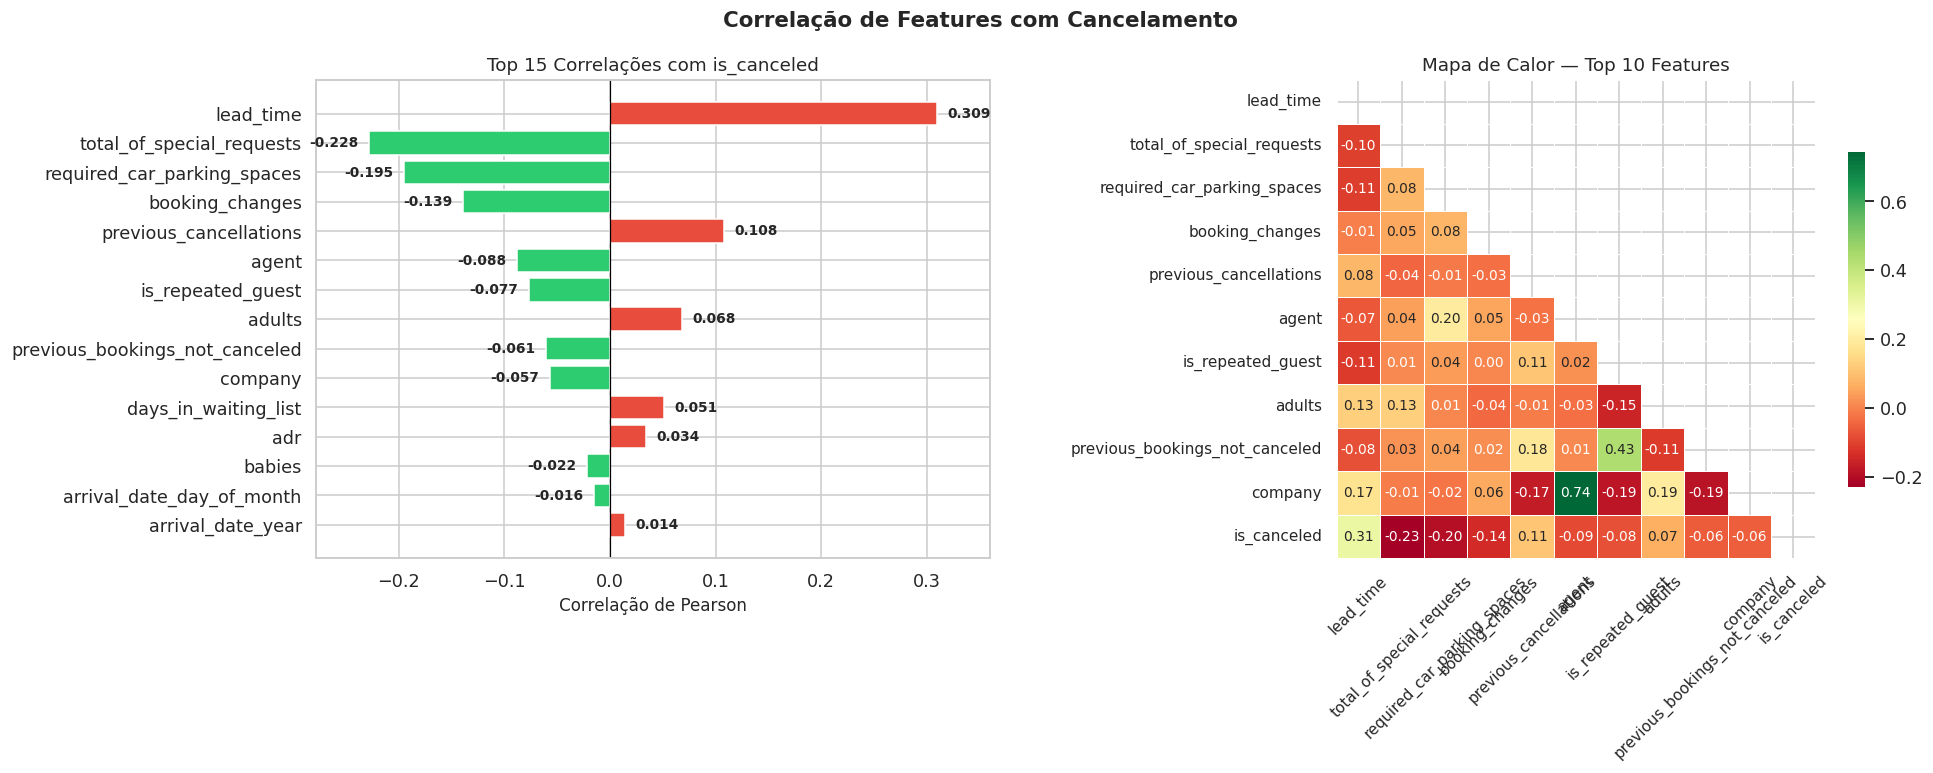

In [12]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# === CORRELAÇÃO COM IS_CANCELED ===
num_cols = df.select_dtypes(include=['int64', 'float64']).columns.tolist()
corr_target = df[num_cols].corr()['is_canceled'].drop('is_canceled').sort_values(key=abs, ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(18, 7))
fig.suptitle('Correlação de Features com Cancelamento', fontsize=14, fontweight='bold')

# 1. Gráfico de Barras Horizontais (Top 15)
top15 = corr_target.head(15)
colors_corr = ['#e74c3c' if v > 0 else '#2ecc71' for v in top15.values]
bars = axes[0].barh(top15.index, top15.values, color=colors_corr, edgecolor='white', linewidth=1)
axes[0].set_title('Top 15 Correlações com is_canceled', fontsize=12)
axes[0].set_xlabel('Correlação de Pearson')
axes[0].axvline(0, color='black', linewidth=0.8)

for bar, val in zip(bars, top15.values):
    offset = 0.01 if val >= 0 else -0.01
    axes[0].text(val + offset, bar.get_y() + bar.get_height()/2,
                 f'{val:.3f}', va='center', ha='left' if val >= 0 else 'right',
                 fontsize=9, fontweight='bold')
axes[0].invert_yaxis()
axes[0].set_xlim(left=min(top15.values) - 0.05, right=max(top15.values) + 0.05)

# 2. Mapa de Calor (Top 10 + Target)
top10_feats = list(corr_target.head(10).index) + ['is_canceled']
heatmap_data = df[top10_feats].corr()
mask = np.triu(np.ones_like(heatmap_data, dtype=bool))

sns.heatmap(heatmap_data, mask=mask, ax=axes[1], cmap='RdYlGn', annot=True, fmt='.2f',
            square=True, linewidths=0.5, cbar_kws={'shrink': 0.7}, annot_kws={'size': 9})
axes[1].set_title('Mapa de Calor — Top 10 Features', fontsize=12)
axes[1].tick_params(axis='x', rotation=45, labelsize=10)
axes[1].tick_params(axis='y', rotation=0, labelsize=10)

plt.tight_layout()
plt.savefig('04_correlacoes.png', bbox_inches='tight', dpi=120)
plt.show()

## Bloco 7 — Análise de Features Categóricas

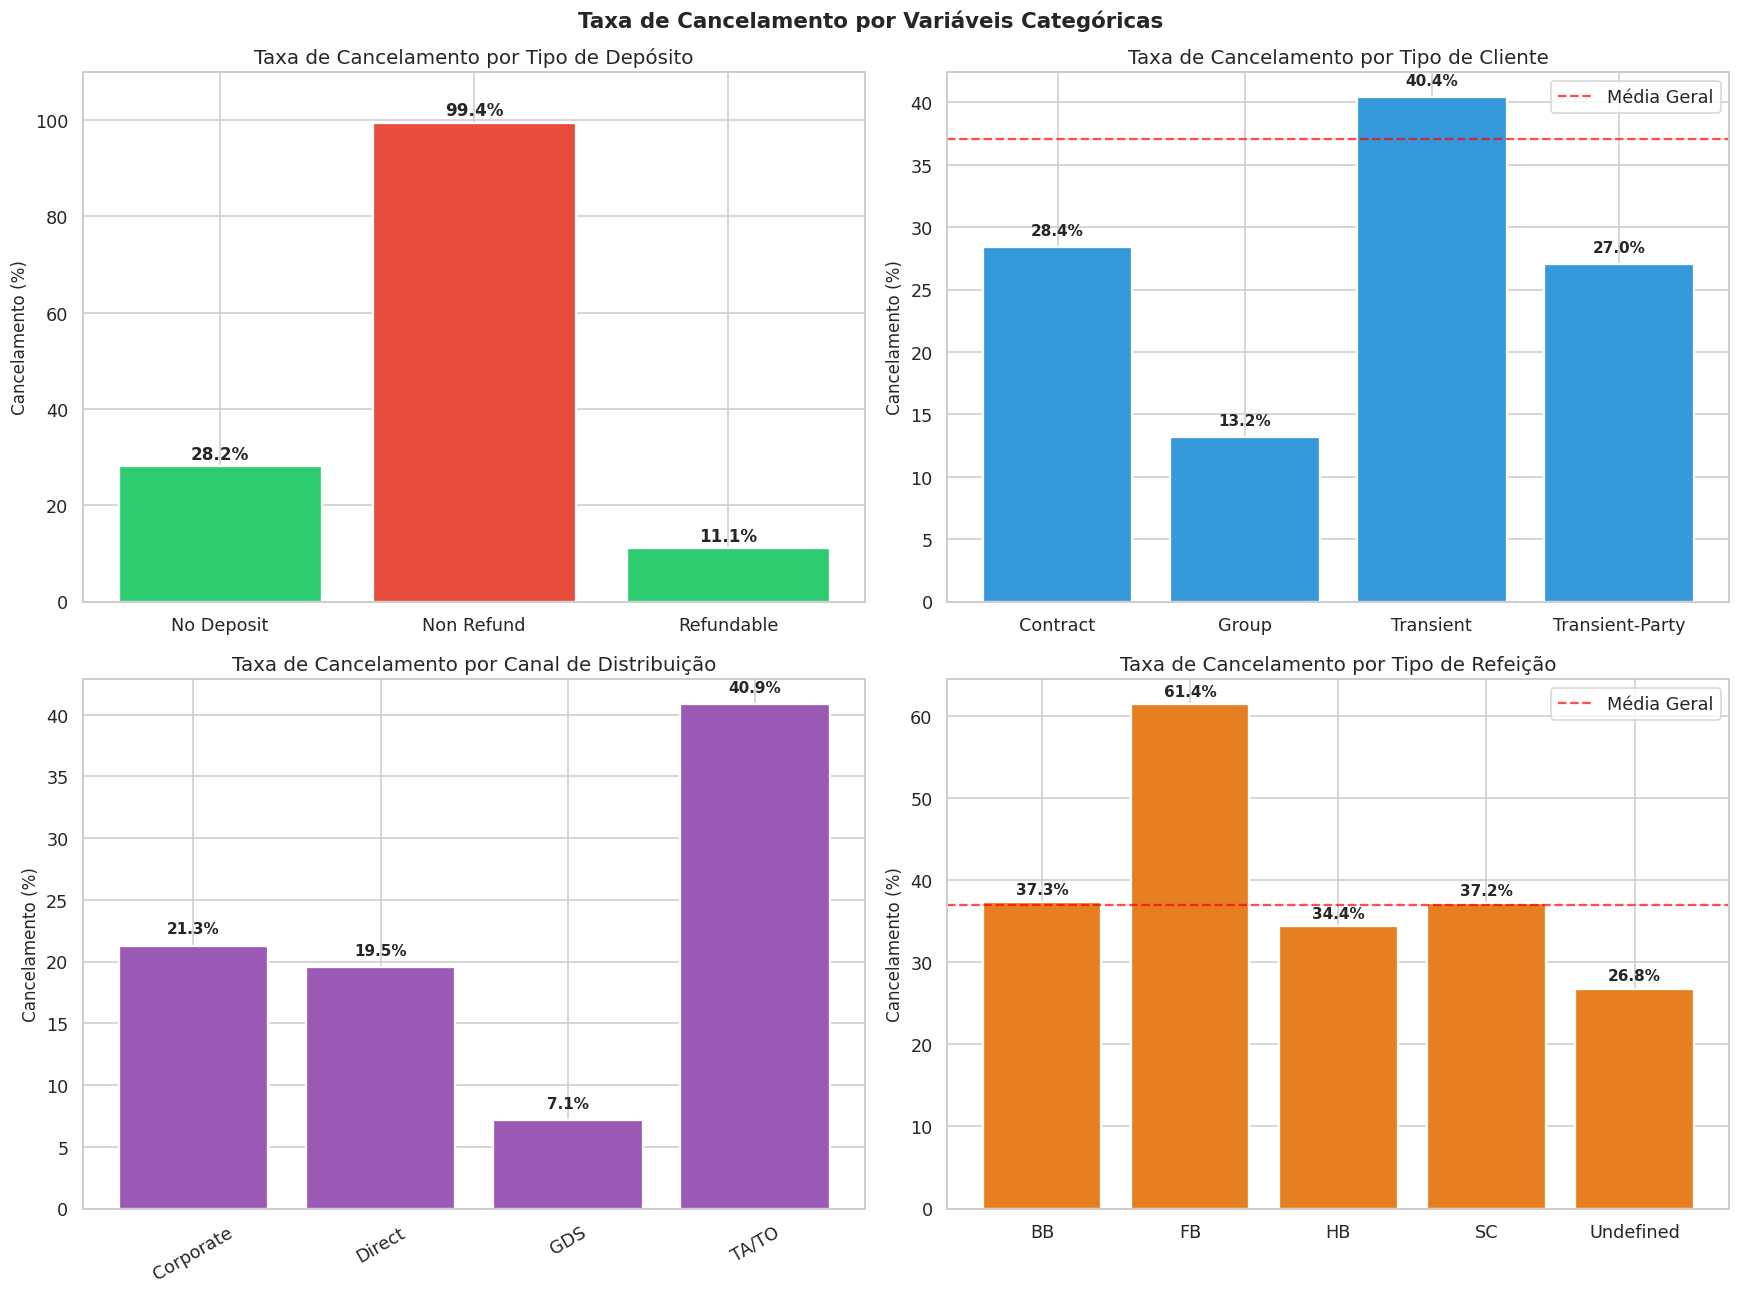

In [13]:
# === CANCELAMENTO POR VARIÁVEIS CATEGÓRICAS ===
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('Taxa de Cancelamento por Variáveis Categóricas', fontsize=14, fontweight='bold')

# 1) Tipo de depósito (deposit_type)
dep_cancel = df.groupby('deposit_type')['is_canceled'].mean() * 100
colors_dep = ['#e74c3c' if v > 50 else '#2ecc71' for v in dep_cancel.values]
bars = axes[0, 0].bar(dep_cancel.index, dep_cancel.values, color=colors_dep, edgecolor='white', linewidth=1.5)
axes[0, 0].set_title('Taxa de Cancelamento por Tipo de Depósito')
axes[0, 0].set_ylabel('Cancelamento (%)')
axes[0, 0].set_ylim(0, 110)
for bar, val in zip(bars, dep_cancel.values):
    axes[0, 0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1.5,
                    f'{val:.1f}%', ha='center', fontsize=11, fontweight='bold')

# 2) Tipo de cliente (customer_type)
cust_cancel = df.groupby('customer_type')['is_canceled'].mean() * 100
axes[0, 1].bar(cust_cancel.index, cust_cancel.values, color='#3498db', edgecolor='white', linewidth=1.5)
axes[0, 1].set_title('Taxa de Cancelamento por Tipo de Cliente')
axes[0, 1].set_ylabel('Cancelamento (%)')
axes[0, 1].axhline(df['is_canceled'].mean() * 100, color='red', linestyle='--', alpha=0.7, label='Média Geral')
axes[0, 1].legend()
for i, val in enumerate(cust_cancel.values):
    axes[0, 1].text(i, val + 1, f'{val:.1f}%', ha='center', fontsize=10, fontweight='bold')

# 3) Canal de distribuição (distribution_channel)
dist_cancel = df.groupby('distribution_channel')['is_canceled'].mean() * 100
axes[1, 0].bar(dist_cancel.index, dist_cancel.values, color='#9b59b6', edgecolor='white', linewidth=1.5)
axes[1, 0].set_title('Taxa de Cancelamento por Canal de Distribuição')
axes[1, 0].set_ylabel('Cancelamento (%)')
axes[1, 0].tick_params(axis='x', rotation=30)
for i, val in enumerate(dist_cancel.values):
    axes[1, 0].text(i, val + 1, f'{val:.1f}%', ha='center', fontsize=10, fontweight='bold')

# 4) Tipo de refeição (meal)
meal_cancel = df.groupby('meal')['is_canceled'].mean() * 100
axes[1, 1].bar(meal_cancel.index, meal_cancel.values, color='#e67e22', edgecolor='white', linewidth=1.5)
axes[1, 1].set_title('Taxa de Cancelamento por Tipo de Refeição')
axes[1, 1].set_ylabel('Cancelamento (%)')
axes[1, 1].axhline(df['is_canceled'].mean() * 100, color='red', linestyle='--', alpha=0.7, label='Média Geral')
axes[1, 1].legend()
for i, val in enumerate(meal_cancel.values):
    axes[1, 1].text(i, val + 1, f'{val:.1f}%', ha='center', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.savefig('05_categoricas.png', bbox_inches='tight', dpi=120)
plt.show()

## Bloco 8 — Verificação de Valores Missing e Outliers

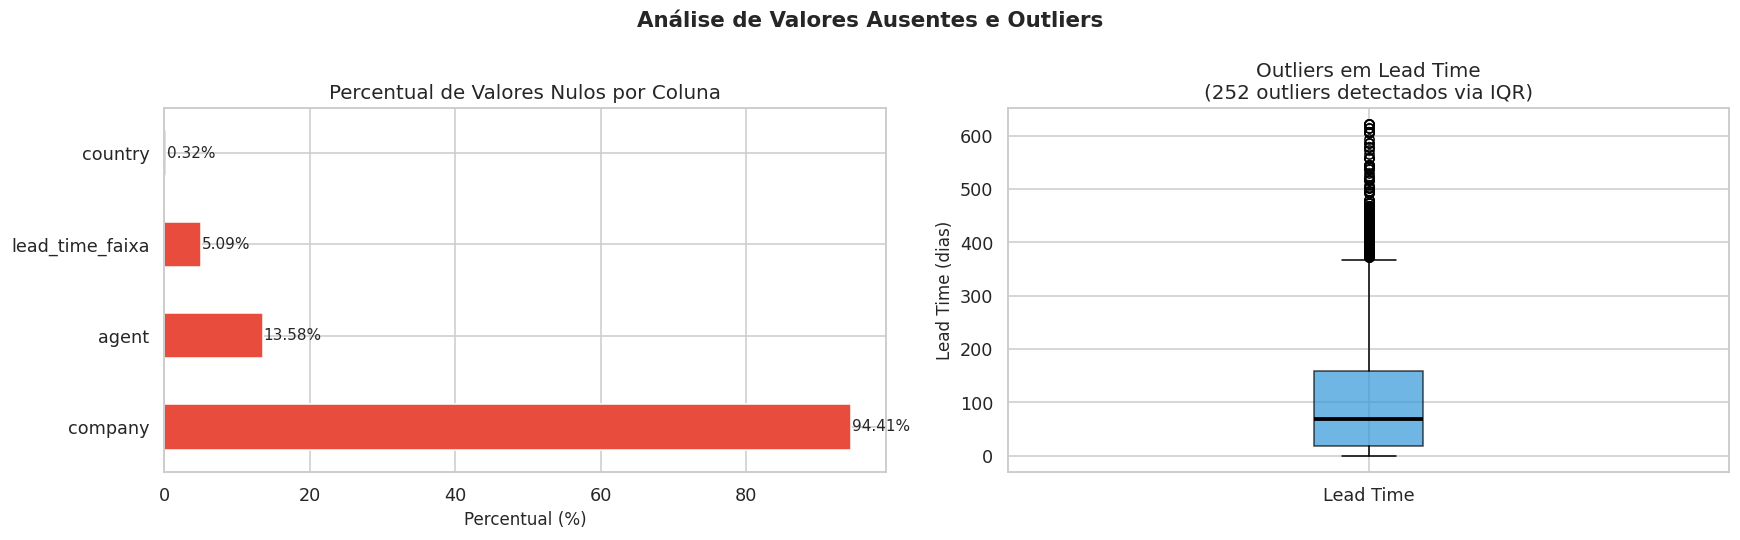


=== RESUMO DE VALORES NULOS ===
                 Nulos  Percentual (%)
company           9441           94.41
agent             1358           13.58
lead_time_faixa    509            5.09
country             32            0.32

=== OUTLIERS EM LEAD_TIME ===
Q1: 18.0 | Q3: 159.0 | IQR: 141.0
Limite inferior: -193.5 | Limite superior: 370.5
Total de outliers: 252 (2.52%)


In [14]:
# === ANÁLISE DE MISSING VALUES ===
missing = df.isnull().sum()
missing_pct = (missing / len(df)) * 100
missing_df = pd.DataFrame({'Nulos': missing, 'Percentual (%)': missing_pct}).sort_values('Nulos', ascending=False)
missing_df = missing_df[missing_df['Nulos'] > 0]

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
fig.suptitle('Análise de Valores Ausentes e Outliers', fontsize=14, fontweight='bold')

if len(missing_df) > 0:
    missing_df['Percentual (%)'].plot(kind='barh', ax=axes[0], color='#e74c3c', edgecolor='white')
    axes[0].set_title('Percentual de Valores Nulos por Coluna')
    axes[0].set_xlabel('Percentual (%)')
    for i, val in enumerate(missing_df['Percentual (%)']):
        axes[0].text(val + 0.1, i, f'{val:.2f}%', va='center', fontsize=10)
else:
    axes[0].text(0.5, 0.5, 'Nenhum valor nulo\nencontrado! ✅',
                 ha='center', va='center', fontsize=14, transform=axes[0].transAxes)
    axes[0].set_title('Valores Nulos — Resultado')
    axes[0].axis('off')

# Outliers em lead_time
Q1 = df['lead_time'].quantile(0.25)
Q3 = df['lead_time'].quantile(0.75)
IQR = Q3 - Q1
lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR
outliers_lt = ((df['lead_time'] < lower) | (df['lead_time'] > upper)).sum()

bp = axes[1].boxplot(df['lead_time'].dropna(), patch_artist=True,
                     medianprops={'color': 'black', 'linewidth': 2.5})
bp['boxes'][0].set_facecolor('#3498db')
bp['boxes'][0].set_alpha(0.7)
axes[1].set_title(f'Outliers em Lead Time\n({outliers_lt} outliers detectados via IQR)')
axes[1].set_ylabel('Lead Time (dias)')
axes[1].set_xticks([1])
axes[1].set_xticklabels(['Lead Time'])

plt.tight_layout()
plt.savefig('06_missing_outliers.png', bbox_inches='tight', dpi=120)
plt.show()

print(f"\n=== RESUMO DE VALORES NULOS ===")
if len(missing_df) > 0:
    print(missing_df)
else:
    print("Nenhum valor nulo encontrado na amostra.")

print(f"\n=== OUTLIERS EM LEAD_TIME ===")
print(f"Q1: {Q1:.1f} | Q3: {Q3:.1f} | IQR: {IQR:.1f}")
print(f"Limite inferior: {lower:.1f} | Limite superior: {upper:.1f}")
print(f"Total de outliers: {outliers_lt} ({outliers_lt/len(df)*100:.2f}%)")

## Bloco 9 — Feature Engineering: Sazonalidade

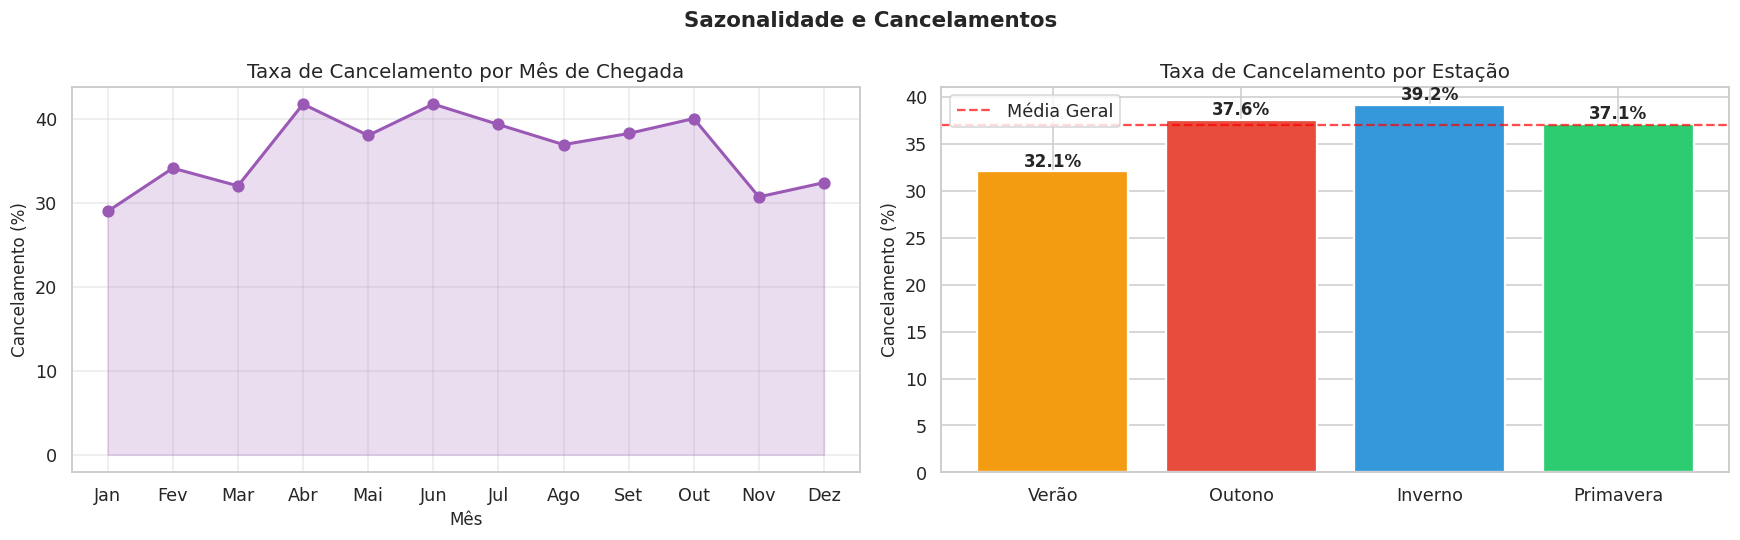

In [15]:
# === ANÁLISE DE SAZONALIDADE ===
# Mapear meses para estações
month_map = {1: 'Jan', 2: 'Fev', 3: 'Mar', 4: 'Abr', 5: 'Mai', 6: 'Jun',
             7: 'Jul', 8: 'Ago', 9: 'Set', 10: 'Out', 11: 'Nov', 12: 'Dez'}
season_map = {1:'Verão', 2:'Verão', 3:'Outono', 4:'Outono', 5:'Outono',
              6:'Inverno', 7:'Inverno', 8:'Inverno', 9:'Primavera', 10:'Primavera',
              11:'Primavera', 12:'Verão'}

df['arrival_month_name'] = df['arrival_date_month'].map({
    'January':1,'February':2,'March':3,'April':4,'May':5,'June':6,
    'July':7,'August':8,'September':9,'October':10,'November':11,'December':12
})
df['estacao'] = df['arrival_month_name'].map(season_map)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
fig.suptitle('Sazonalidade e Cancelamentos', fontsize=14, fontweight='bold')

# Por mês
month_cancel = df.groupby('arrival_month_name')['is_canceled'].mean() * 100
month_cancel = month_cancel.reindex(range(1, 13))
axes[0].plot(range(1, 13), month_cancel.values, 'o-', color='#9b59b6', linewidth=2, markersize=7)
axes[0].fill_between(range(1, 13), month_cancel.values, alpha=0.2, color='#9b59b6')
axes[0].set_title('Taxa de Cancelamento por Mês de Chegada')
axes[0].set_xlabel('Mês')
axes[0].set_ylabel('Cancelamento (%)')
axes[0].set_xticks(range(1, 13))
axes[0].set_xticklabels(['Jan','Fev','Mar','Abr','Mai','Jun','Jul','Ago','Set','Out','Nov','Dez'])
axes[0].grid(True, alpha=0.4)

# Por estação
estacao_order = ['Verão', 'Outono', 'Inverno', 'Primavera']
estacao_cancel = df.groupby('estacao')['is_canceled'].mean() * 100
estacao_cancel = estacao_cancel.reindex(estacao_order)
season_colors = ['#f39c12', '#e74c3c', '#3498db', '#2ecc71']
bars = axes[1].bar(estacao_cancel.index, estacao_cancel.values, color=season_colors, edgecolor='white', linewidth=1.5)
axes[1].set_title('Taxa de Cancelamento por Estação')
axes[1].set_ylabel('Cancelamento (%)')
axes[1].axhline(df['is_canceled'].mean() * 100, color='red', linestyle='--', alpha=0.7, label='Média Geral')
axes[1].legend()
for bar, val in zip(bars, estacao_cancel.values):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
                 f'{val:.1f}%', ha='center', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.savefig('07_sazonalidade.png', bbox_inches='tight', dpi=120)
plt.show()

---

# ETAPA 2 | Pré-processamento

## Bloco 10 — Seleção de Features e Tratamento de Nulos

In [16]:
# === FEATURES SELECIONADAS ===
features_num = [
    'lead_time',
    'stays_in_weekend_nights',
    'stays_in_week_nights',
    'adults',
    'children',
    'babies',
    'previous_cancellations',
    'previous_bookings_not_canceled',
    'booking_changes',
    'adr',
    'total_of_special_requests',
    'days_in_waiting_list',
    'required_car_parking_spaces'
]

features_cat = [
    'hotel',
    'meal',
    'market_segment',
    'distribution_channel',
    'reserved_room_type',
    'deposit_type',
    'customer_type',
    'estacao'
]

TARGET = 'is_canceled'

# Remover colunas com alta cardinalidade ou irrelevantes
features_all = features_num + features_cat
df_model = df[features_all + [TARGET]].copy()

# Tratar valores nulos numéricos
for col in features_num:
    if df_model[col].isnull().sum() > 0:
        df_model[col].fillna(df_model[col].median(), inplace=True)

# Tratar valores nulos categóricos
for col in features_cat:
    if df_model[col].isnull().sum() > 0:
        df_model[col].fillna(df_model[col].mode()[0], inplace=True)

print(f"Dataset para modelagem: {df_model.shape}")
print(f"Nulos restantes: {df_model.isnull().sum().sum()}")
print(f"\nFeatures numéricas ({len(features_num)}): {features_num}")
print(f"\nFeatures categóricas ({len(features_cat)}): {features_cat}")

Dataset para modelagem: (10000, 22)
Nulos restantes: 0

Features numéricas (13): ['lead_time', 'stays_in_weekend_nights', 'stays_in_week_nights', 'adults', 'children', 'babies', 'previous_cancellations', 'previous_bookings_not_canceled', 'booking_changes', 'adr', 'total_of_special_requests', 'days_in_waiting_list', 'required_car_parking_spaces']

Features categóricas (8): ['hotel', 'meal', 'market_segment', 'distribution_channel', 'reserved_room_type', 'deposit_type', 'customer_type', 'estacao']


## Bloco 11 — Encoding e Normalização

In [17]:
# === ENCODING DE VARIÁVEIS CATEGÓRICAS ===
# OneHotEncoder para poucas categorias
print("Cardinalidade das variáveis categóricas:")
for col in features_cat:
    n = df_model[col].nunique()
    print(f"  {col}: {n} categorias")

Cardinalidade das variáveis categóricas:
  hotel: 2 categorias
  meal: 5 categorias
  market_segment: 7 categorias
  distribution_channel: 4 categorias
  reserved_room_type: 10 categorias
  deposit_type: 3 categorias
  customer_type: 4 categorias
  estacao: 4 categorias


In [18]:
# === DIVISÃO TREINO / VALIDAÇÃO / TESTE ===
X = df_model.drop(TARGET, axis=1)
y = df_model[TARGET]

# Split estratificado: 70% treino | 15% validação | 15% teste
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.30, stratify=y, random_state=RANDOM_STATE
)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, stratify=y_temp, random_state=RANDOM_STATE
)

print("=== DIVISÃO DO DATASET ===")
print(f"Treino:    {X_train.shape[0]:,} amostras ({X_train.shape[0]/len(X)*100:.1f}%)")
print(f"Validação: {X_val.shape[0]:,} amostras ({X_val.shape[0]/len(X)*100:.1f}%)")
print(f"Teste:     {X_test.shape[0]:,} amostras ({X_test.shape[0]/len(X)*100:.1f}%)")
print(f"\nTaxa de cancelamento — Treino: {y_train.mean():.2%} | Val: {y_val.mean():.2%} | Teste: {y_test.mean():.2%}")

=== DIVISÃO DO DATASET ===
Treino:    7,000 amostras (70.0%)
Validação: 1,500 amostras (15.0%)
Teste:     1,500 amostras (15.0%)

Taxa de cancelamento — Treino: 37.04% | Val: 37.00% | Teste: 37.07%


In [19]:
# === PIPELINE DE PRÉ-PROCESSAMENTO ===
# Pipeline para numéricas: imputer + scaler
num_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

# Pipeline para categóricas: imputer + OHE
cat_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('ohe', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

# ColumnTransformer
preprocessor = ColumnTransformer([
    ('num', num_pipeline, features_num),
    ('cat', cat_pipeline, features_cat)
])

# Aplicar pré-processamento
X_train_proc = preprocessor.fit_transform(X_train)
X_val_proc   = preprocessor.transform(X_val)
X_test_proc  = preprocessor.transform(X_test)

# Nomes das features pós-encoding
ohe_feature_names = preprocessor.named_transformers_['cat']['ohe'].get_feature_names_out(features_cat)
feature_names_final = features_num + list(ohe_feature_names)

print(f"Shape pós-processamento:")
print(f"  Treino: {X_train_proc.shape}")
print(f"  Validação: {X_val_proc.shape}")
print(f"  Teste: {X_test_proc.shape}")
print(f"  Total de features após encoding: {X_train_proc.shape[1]}")

Shape pós-processamento:
  Treino: (7000, 52)
  Validação: (1500, 52)
  Teste: (1500, 52)
  Total de features após encoding: 52


---

# ETAPA 3 | Comparação de Classificadores

## Bloco 12 — Modelo 1: Regressão Logística

In [20]:
# === MODELO 1: LOGISTIC REGRESSION ===
lr = LogisticRegression(max_iter=1000, random_state=RANDOM_STATE, solver='lbfgs')
lr.fit(X_train_proc, y_train)

# Avaliação
y_pred_lr = lr.predict(X_test_proc)
y_prob_lr = lr.predict_proba(X_test_proc)[:, 1]

acc_lr    = accuracy_score(y_test, y_pred_lr)
prec_lr   = precision_score(y_test, y_pred_lr)
rec_lr    = recall_score(y_test, y_pred_lr)
f1_lr     = f1_score(y_test, y_pred_lr)
auc_lr    = roc_auc_score(y_test, y_prob_lr)

print("=== LOGISTIC REGRESSION ===")
print(f"Acurácia:  {acc_lr:.4f}")
print(f"Precisão:  {prec_lr:.4f}")
print(f"Recall:    {rec_lr:.4f}")
print(f"F1-Score:  {f1_lr:.4f}")
print(f"AUC-ROC:   {auc_lr:.4f}")
print()
print(classification_report(y_test, y_pred_lr, target_names=['Mantida', 'Cancelada']))

=== LOGISTIC REGRESSION ===
Acurácia:  0.7913
Precisão:  0.8015
Recall:    0.5809
F1-Score:  0.6736
AUC-ROC:   0.8334

              precision    recall  f1-score   support

     Mantida       0.79      0.92      0.85       944
   Cancelada       0.80      0.58      0.67       556

    accuracy                           0.79      1500
   macro avg       0.79      0.75      0.76      1500
weighted avg       0.79      0.79      0.78      1500



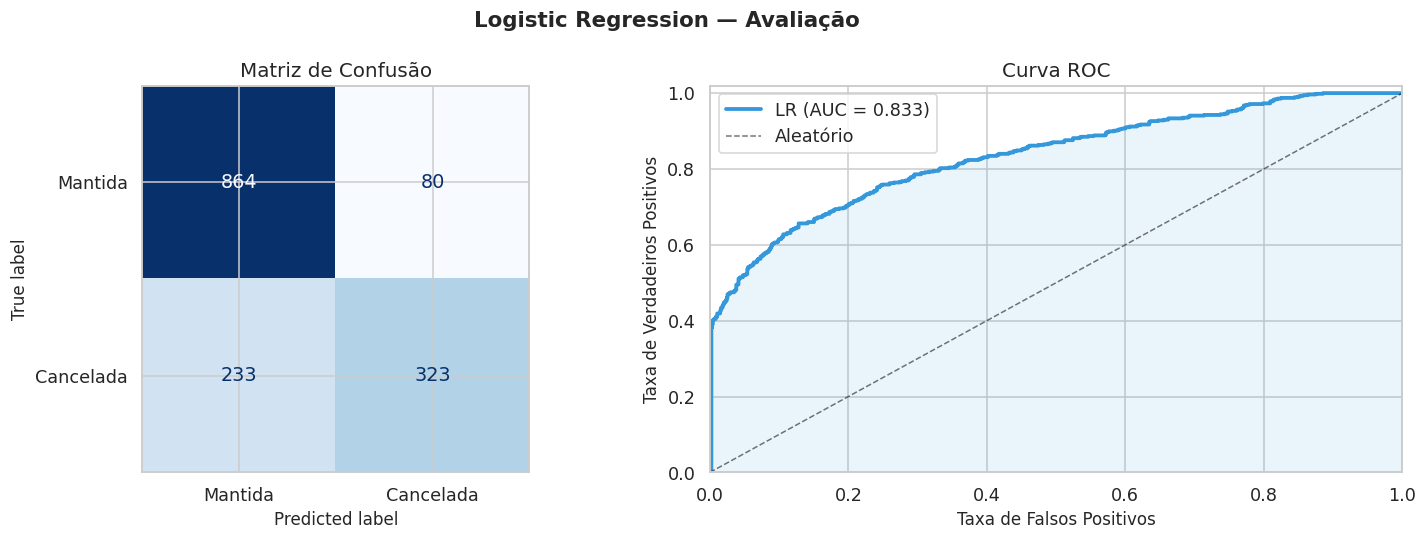

In [21]:
# === VISUALIZAÇÕES — LOGISTIC REGRESSION ===
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Logistic Regression — Avaliação', fontsize=14, fontweight='bold')

# Matriz de confusão
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred_lr, display_labels=['Mantida', 'Cancelada'],
    cmap='Blues', ax=axes[0], colorbar=False
)
axes[0].set_title('Matriz de Confusão')

# Curva ROC
fpr_lr, tpr_lr, _ = roc_curve(y_test, y_prob_lr)
axes[1].plot(fpr_lr, tpr_lr, color='#3498db', linewidth=2.5, label=f'LR (AUC = {auc_lr:.3f})')
axes[1].plot([0, 1], [0, 1], 'k--', linewidth=1, alpha=0.6, label='Aleatório')
axes[1].fill_between(fpr_lr, tpr_lr, alpha=0.1, color='#3498db')
axes[1].set_title('Curva ROC')
axes[1].set_xlabel('Taxa de Falsos Positivos')
axes[1].set_ylabel('Taxa de Verdadeiros Positivos')
axes[1].legend()
axes[1].set_xlim([0, 1])
axes[1].set_ylim([0, 1.02])

plt.tight_layout()
plt.savefig('08_lr_avaliacao.png', bbox_inches='tight', dpi=120)
plt.show()

## Bloco 13 — Modelo 2: Random Forest

In [22]:
# === MODELO 2: RANDOM FOREST ===
rf = RandomForestClassifier(n_estimators=100, max_depth=8, random_state=RANDOM_STATE, n_jobs=-1)
rf.fit(X_train_proc, y_train)

# Avaliação
y_pred_rf = rf.predict(X_test_proc)
y_prob_rf = rf.predict_proba(X_test_proc)[:, 1]

acc_rf    = accuracy_score(y_test, y_pred_rf)
prec_rf   = precision_score(y_test, y_pred_rf)
rec_rf    = recall_score(y_test, y_pred_rf)
f1_rf     = f1_score(y_test, y_pred_rf)
auc_rf    = roc_auc_score(y_test, y_prob_rf)

print("=== RANDOM FOREST ===")
print(f"Acurácia:  {acc_rf:.4f}")
print(f"Precisão:  {prec_rf:.4f}")
print(f"Recall:    {rec_rf:.4f}")
print(f"F1-Score:  {f1_rf:.4f}")
print(f"AUC-ROC:   {auc_rf:.4f}")
print()
print(classification_report(y_test, y_pred_rf, target_names=['Mantida', 'Cancelada']))

=== RANDOM FOREST ===
Acurácia:  0.7967
Precisão:  0.8910
Recall:    0.5144
F1-Score:  0.6522
AUC-ROC:   0.8588

              precision    recall  f1-score   support

     Mantida       0.77      0.96      0.86       944
   Cancelada       0.89      0.51      0.65       556

    accuracy                           0.80      1500
   macro avg       0.83      0.74      0.75      1500
weighted avg       0.82      0.80      0.78      1500



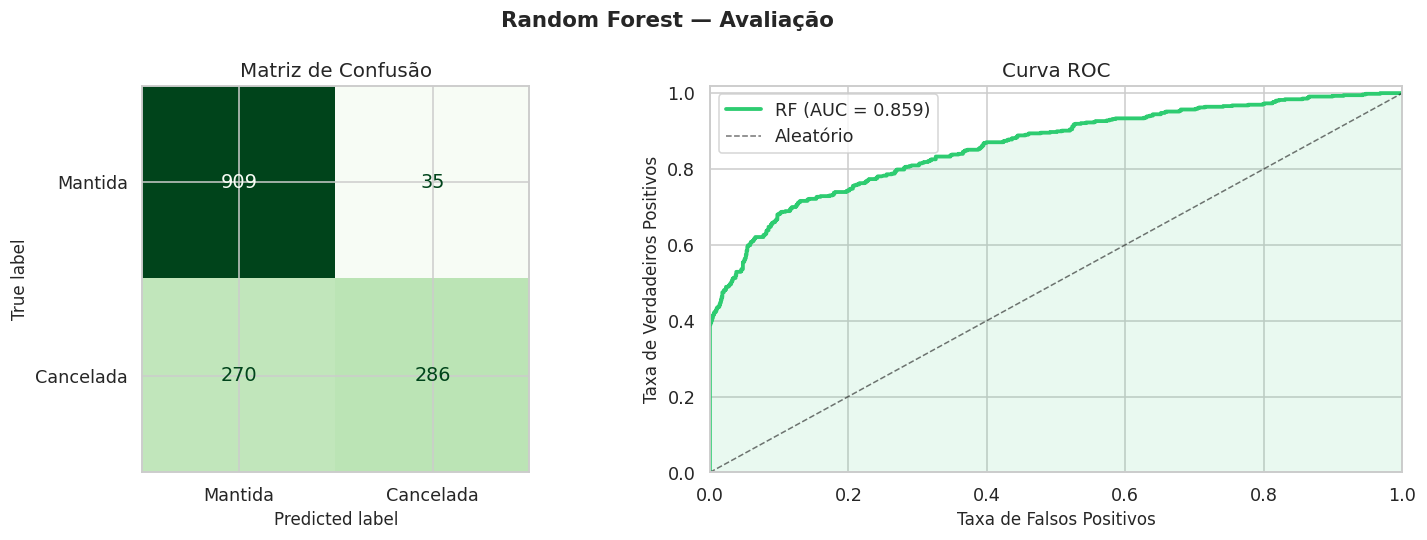

In [23]:
# === VISUALIZAÇÕES — RANDOM FOREST ===
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Random Forest — Avaliação', fontsize=14, fontweight='bold')

ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred_rf, display_labels=['Mantida', 'Cancelada'],
    cmap='Greens', ax=axes[0], colorbar=False
)
axes[0].set_title('Matriz de Confusão')

fpr_rf, tpr_rf, _ = roc_curve(y_test, y_prob_rf)
axes[1].plot(fpr_rf, tpr_rf, color='#2ecc71', linewidth=2.5, label=f'RF (AUC = {auc_rf:.3f})')
axes[1].plot([0, 1], [0, 1], 'k--', linewidth=1, alpha=0.6, label='Aleatório')
axes[1].fill_between(fpr_rf, tpr_rf, alpha=0.1, color='#2ecc71')
axes[1].set_title('Curva ROC')
axes[1].set_xlabel('Taxa de Falsos Positivos')
axes[1].set_ylabel('Taxa de Verdadeiros Positivos')
axes[1].legend()
axes[1].set_xlim([0, 1])
axes[1].set_ylim([0, 1.02])

plt.tight_layout()
plt.savefig('09_rf_avaliacao.png', bbox_inches='tight', dpi=120)
plt.show()

## Bloco 14 — Modelo 3: Gradient Boosting

In [24]:
# === MODELO 3: GRADIENT BOOSTING ===
gb = GradientBoostingClassifier(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=4,
    random_state=RANDOM_STATE
)
gb.fit(X_train_proc, y_train)

# Avaliação
y_pred_gb = gb.predict(X_test_proc)
y_prob_gb = gb.predict_proba(X_test_proc)[:, 1]

acc_gb    = accuracy_score(y_test, y_pred_gb)
prec_gb   = precision_score(y_test, y_pred_gb)
rec_gb    = recall_score(y_test, y_pred_gb)
f1_gb     = f1_score(y_test, y_pred_gb)
auc_gb    = roc_auc_score(y_test, y_prob_gb)

print("=== GRADIENT BOOSTING ===")
print(f"Acurácia:  {acc_gb:.4f}")
print(f"Precisão:  {prec_gb:.4f}")
print(f"Recall:    {rec_gb:.4f}")
print(f"F1-Score:  {f1_gb:.4f}")
print(f"AUC-ROC:   {auc_gb:.4f}")
print()
print(classification_report(y_test, y_pred_gb, target_names=['Mantida', 'Cancelada']))

=== GRADIENT BOOSTING ===
Acurácia:  0.8080
Precisão:  0.8160
Recall:    0.6223
F1-Score:  0.7061
AUC-ROC:   0.8661

              precision    recall  f1-score   support

     Mantida       0.80      0.92      0.86       944
   Cancelada       0.82      0.62      0.71       556

    accuracy                           0.81      1500
   macro avg       0.81      0.77      0.78      1500
weighted avg       0.81      0.81      0.80      1500



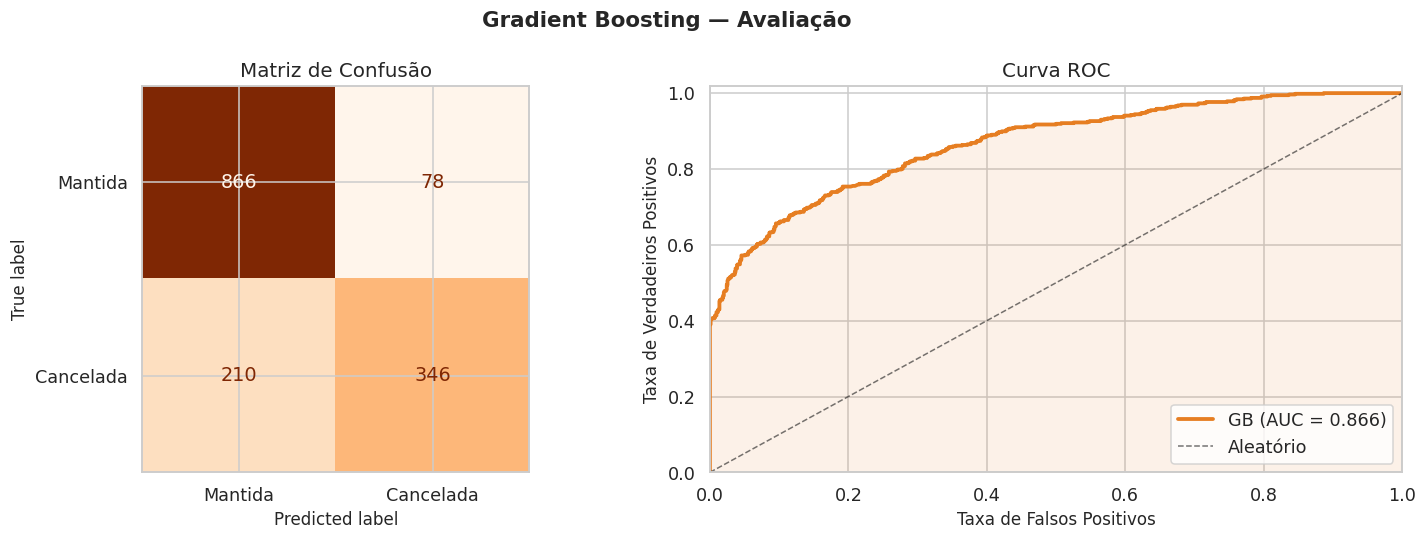

In [25]:
# === VISUALIZAÇÕES — GRADIENT BOOSTING ===
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Gradient Boosting — Avaliação', fontsize=14, fontweight='bold')

ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred_gb, display_labels=['Mantida', 'Cancelada'],
    cmap='Oranges', ax=axes[0], colorbar=False
)
axes[0].set_title('Matriz de Confusão')

fpr_gb, tpr_gb, _ = roc_curve(y_test, y_prob_gb)
axes[1].plot(fpr_gb, tpr_gb, color='#e67e22', linewidth=2.5, label=f'GB (AUC = {auc_gb:.3f})')
axes[1].plot([0, 1], [0, 1], 'k--', linewidth=1, alpha=0.6, label='Aleatório')
axes[1].fill_between(fpr_gb, tpr_gb, alpha=0.1, color='#e67e22')
axes[1].set_title('Curva ROC')
axes[1].set_xlabel('Taxa de Falsos Positivos')
axes[1].set_ylabel('Taxa de Verdadeiros Positivos')
axes[1].legend()
axes[1].set_xlim([0, 1])
axes[1].set_ylim([0, 1.02])

plt.tight_layout()
plt.savefig('10_gb_avaliacao.png', bbox_inches='tight', dpi=120)
plt.show()

## Bloco 15 — Stratified K-Fold (k=5)

In [26]:
# === STRATIFIED K-FOLD (k=5) ===
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

modelos = {
    'Logistic Regression': lr,
    'Random Forest':        rf,
    'Gradient Boosting':    gb
}

cv_results = {}
print("=== VALIDAÇÃO CRUZADA ESTRATIFICADA (k=5) ===")

# Usar dados de treino+val para CV
X_cv = np.vstack([X_train_proc, X_val_proc])
y_cv = np.concatenate([y_train, y_val])

for nome, modelo in modelos.items():
    scores_acc = cross_val_score(modelo, X_cv, y_cv, cv=skf, scoring='accuracy')
    scores_f1  = cross_val_score(modelo, X_cv, y_cv, cv=skf, scoring='f1')
    scores_auc = cross_val_score(modelo, X_cv, y_cv, cv=skf, scoring='roc_auc')
    cv_results[nome] = {
        'acc_mean': scores_acc.mean(), 'acc_std': scores_acc.std(),
        'f1_mean':  scores_f1.mean(),  'f1_std':  scores_f1.std(),
        'auc_mean': scores_auc.mean(), 'auc_std': scores_auc.std()
    }
    print(f"\n{nome}:")
    print(f"  Acurácia: {scores_acc.mean():.4f} ± {scores_acc.std():.4f}")
    print(f"  F1-Score: {scores_f1.mean():.4f} ± {scores_f1.std():.4f}")
    print(f"  AUC-ROC:  {scores_auc.mean():.4f} ± {scores_auc.std():.4f}")

=== VALIDAÇÃO CRUZADA ESTRATIFICADA (k=5) ===

Logistic Regression:
  Acurácia: 0.8066 ± 0.0072
  F1-Score: 0.6960 ± 0.0137
  AUC-ROC:  0.8493 ± 0.0102

Random Forest:
  Acurácia: 0.8036 ± 0.0055
  F1-Score: 0.6596 ± 0.0175
  AUC-ROC:  0.8744 ± 0.0091

Gradient Boosting:
  Acurácia: 0.8219 ± 0.0104
  F1-Score: 0.7250 ± 0.0179
  AUC-ROC:  0.8793 ± 0.0058


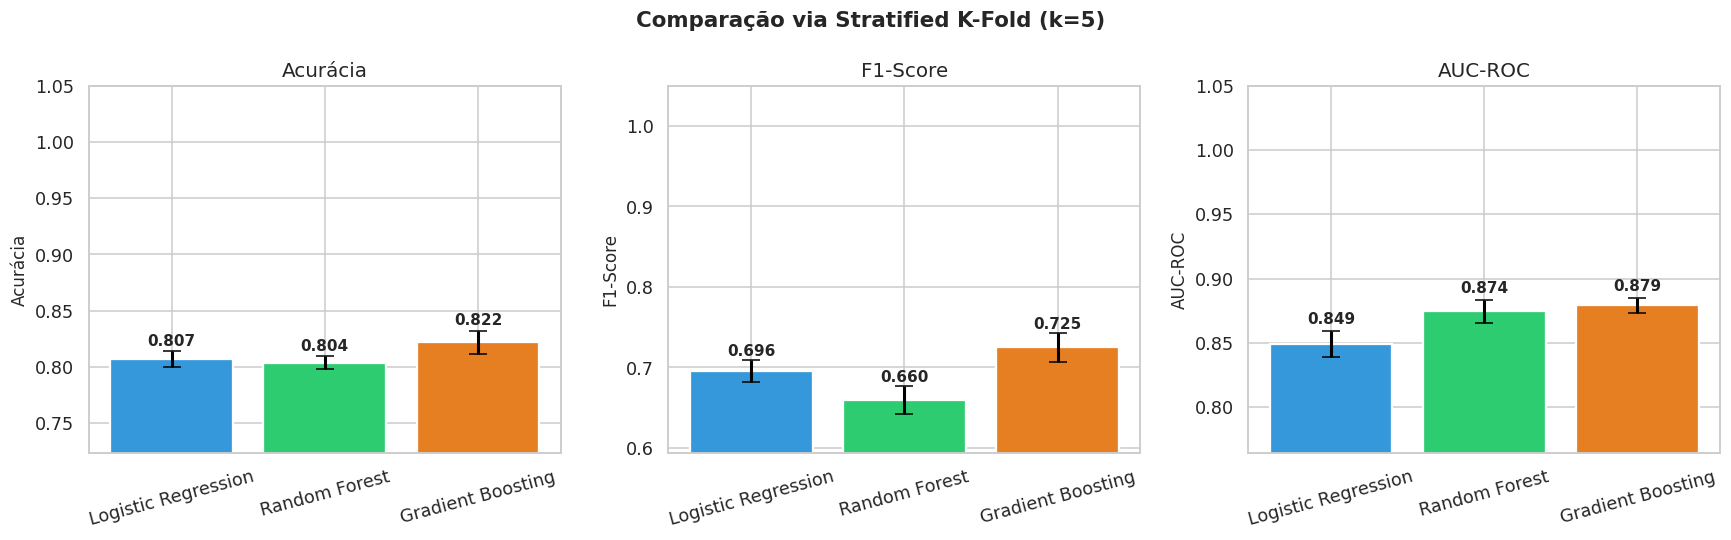

In [27]:
# === VISUALIZAÇÃO DO K-FOLD ===
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('Comparação via Stratified K-Fold (k=5)', fontsize=14, fontweight='bold')

nomes = list(cv_results.keys())
cores = ['#3498db', '#2ecc71', '#e67e22']
metrics = [('acc_mean', 'acc_std', 'Acurácia'), ('f1_mean', 'f1_std', 'F1-Score'), ('auc_mean', 'auc_std', 'AUC-ROC')]

for ax, (mean_key, std_key, title) in zip(axes, metrics):
    means = [cv_results[n][mean_key] for n in nomes]
    stds  = [cv_results[n][std_key] for n in nomes]
    bars = ax.bar(nomes, means, color=cores, edgecolor='white', linewidth=1.5)
    ax.errorbar(nomes, means, yerr=stds, fmt='none', color='black', capsize=6, linewidth=2)
    ax.set_title(title)
    ax.set_ylabel(title)
    ax.set_ylim(min(means) * 0.9, 1.05)
    ax.tick_params(axis='x', rotation=15)
    for bar, val, std in zip(bars, means, stds):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + std + 0.005,
                f'{val:.3f}', ha='center', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.savefig('11_kfold_comparacao.png', bbox_inches='tight', dpi=120)
plt.show()

## Bloco 16 — Curvas ROC Comparativas

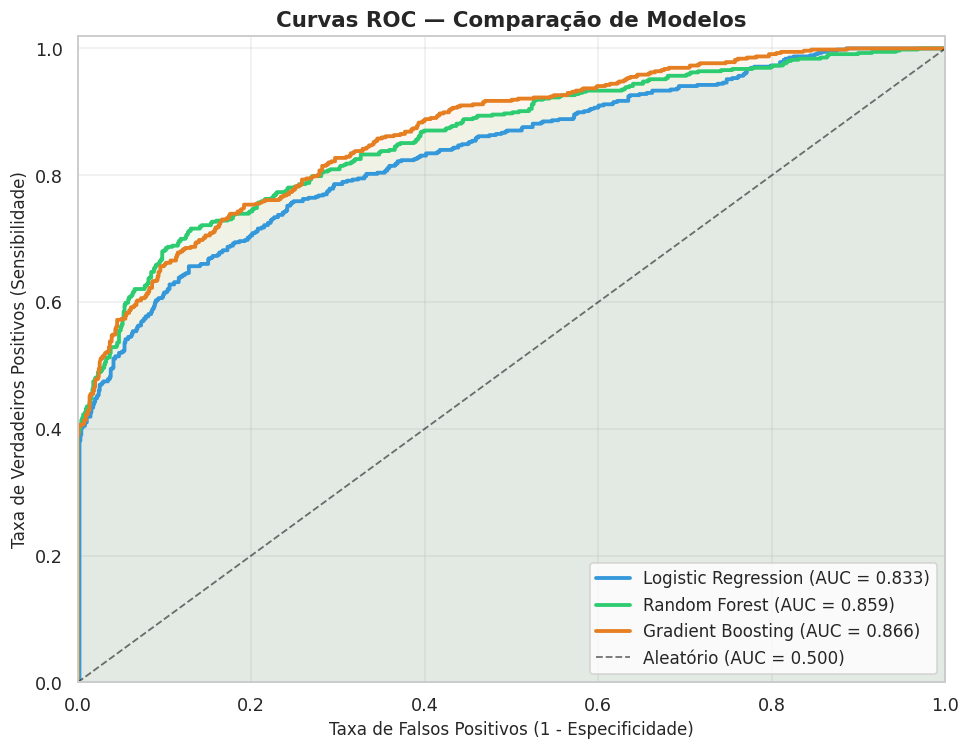

In [28]:
# === CURVAS ROC — TODOS OS MODELOS ===
fig, ax = plt.subplots(figsize=(9, 7))

modelos_roc = [
    ('Logistic Regression', fpr_lr, tpr_lr, auc_lr, '#3498db'),
    ('Random Forest',        fpr_rf, tpr_rf, auc_rf, '#2ecc71'),
    ('Gradient Boosting',    fpr_gb, tpr_gb, auc_gb, '#e67e22'),
]

for nome, fpr, tpr, auc, cor in modelos_roc:
    ax.plot(fpr, tpr, linewidth=2.5, color=cor, label=f'{nome} (AUC = {auc:.3f})')
    ax.fill_between(fpr, tpr, alpha=0.07, color=cor)

ax.plot([0, 1], [0, 1], 'k--', linewidth=1.2, alpha=0.6, label='Aleatório (AUC = 0.500)')
ax.set_title('Curvas ROC — Comparação de Modelos', fontsize=14, fontweight='bold')
ax.set_xlabel('Taxa de Falsos Positivos (1 - Especificidade)')
ax.set_ylabel('Taxa de Verdadeiros Positivos (Sensibilidade)')
ax.legend(loc='lower right', fontsize=11)
ax.set_xlim([0, 1])
ax.set_ylim([0, 1.02])
ax.grid(True, alpha=0.35)

plt.tight_layout()
plt.savefig('12_roc_comparativo.png', bbox_inches='tight', dpi=120)
plt.show()

## Bloco 17 — Feature Importance

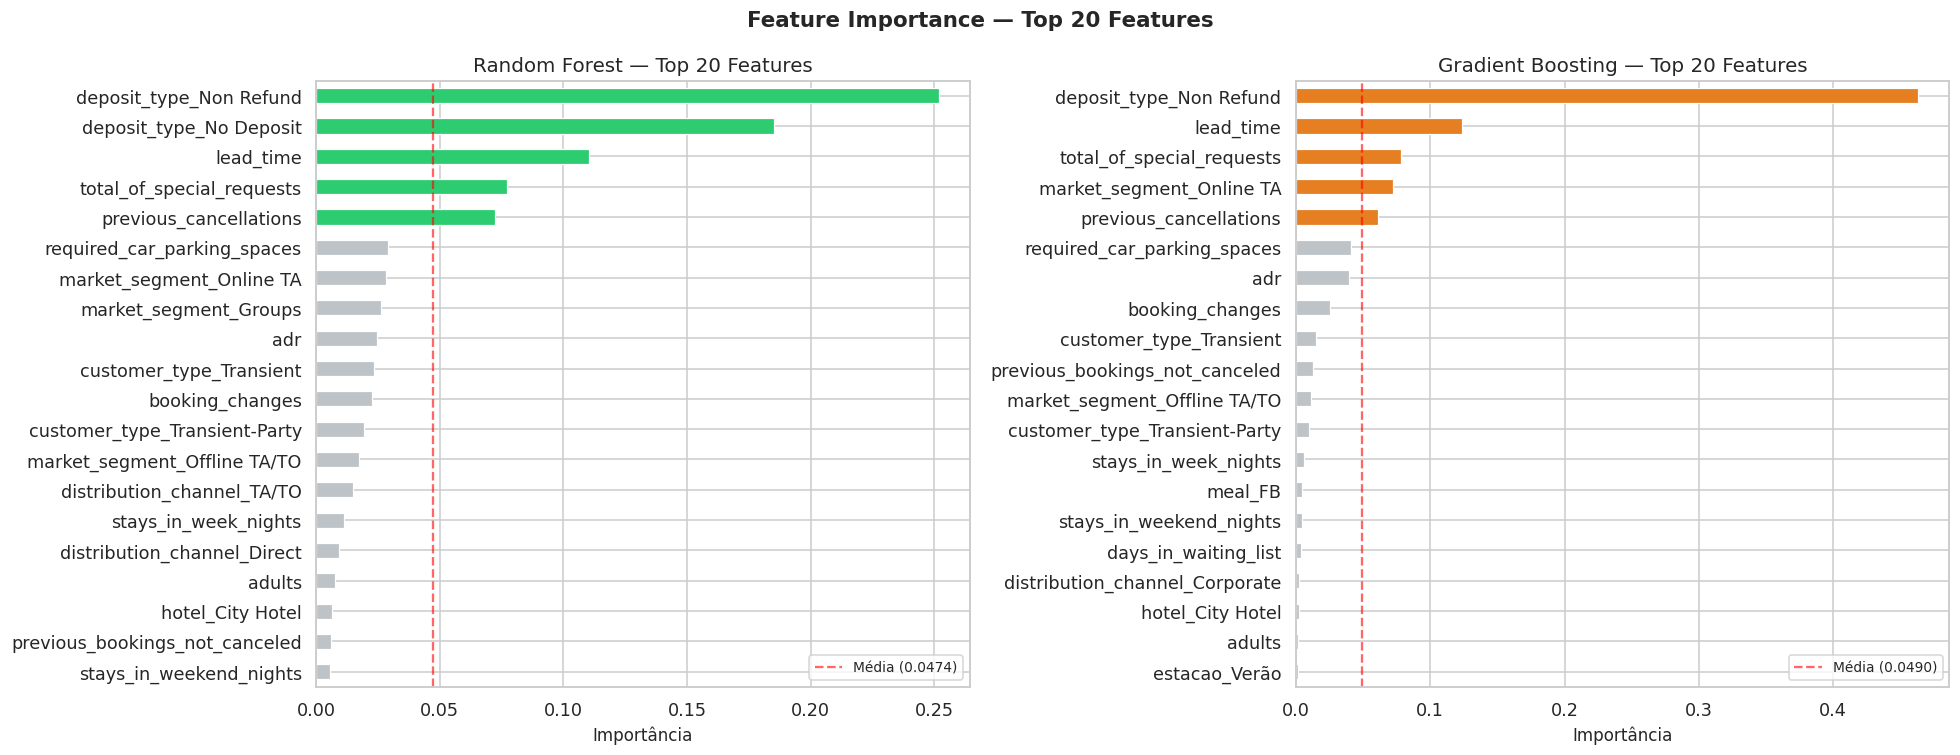

In [29]:
# === FEATURE IMPORTANCE — RANDOM FOREST E GRADIENT BOOSTING ===
fig, axes = plt.subplots(1, 2, figsize=(18, 7))
fig.suptitle('Feature Importance — Top 20 Features', fontsize=14, fontweight='bold')

for ax, modelo, nome, cor in [
    (axes[0], rf, 'Random Forest', '#2ecc71'),
    (axes[1], gb, 'Gradient Boosting', '#e67e22')
]:
    importances = pd.Series(modelo.feature_importances_, index=feature_names_final)
    top20 = importances.sort_values(ascending=False).head(20)
    top20_sorted = top20.sort_values(ascending=True)

    colors_feat = [cor if v >= top20.mean() else '#bdc3c7' for v in top20_sorted.values]
    top20_sorted.plot(kind='barh', ax=ax, color=colors_feat, edgecolor='white', linewidth=0.8)
    ax.set_title(f'{nome} — Top 20 Features')
    ax.set_xlabel('Importância')
    ax.axvline(x=top20.mean(), color='red', linestyle='--', alpha=0.6, label=f'Média ({top20.mean():.4f})')
    ax.legend(fontsize=9)

plt.tight_layout()
plt.savefig('13_feature_importance.png', bbox_inches='tight', dpi=120)
plt.show()

---

# ETAPA 4 | Análise Comparativa e Conclusões

## Bloco 18 — Tabela Comparativa Final

In [30]:
# === TABELA COMPARATIVA FINAL ===
resultados = {
    'Modelo': ['Logistic Regression', 'Random Forest', 'Gradient Boosting'],
    'Acurácia': [acc_lr, acc_rf, acc_gb],
    'Precisão': [prec_lr, prec_rf, prec_gb],
    'Recall':   [rec_lr, rec_rf, rec_gb],
    'F1-Score': [f1_lr, f1_rf, f1_gb],
    'AUC-ROC':  [auc_lr, auc_rf, auc_gb],
    'AUC CV (média)': [
        cv_results['Logistic Regression']['auc_mean'],
        cv_results['Random Forest']['auc_mean'],
        cv_results['Gradient Boosting']['auc_mean']
    ]
}

df_resultados = pd.DataFrame(resultados)
df_resultados_fmt = df_resultados.copy()
for col in ['Acurácia', 'Precisão', 'Recall', 'F1-Score', 'AUC-ROC', 'AUC CV (média)']:
    df_resultados_fmt[col] = df_resultados_fmt[col].apply(lambda x: f'{x:.4f}')

print("=" * 85)
print("TABELA COMPARATIVA — DESAFIO 07 | CANCELAMENTO DE HOTEL")
print("=" * 85)
print(df_resultados_fmt.to_string(index=False))
print("=" * 85)

# Identificar melhor modelo
melhor_idx = df_resultados['F1-Score'].idxmax()
melhor = df_resultados.loc[melhor_idx, 'Modelo']
print(f"\n🏆 Melhor modelo (F1-Score): {melhor}")

TABELA COMPARATIVA — DESAFIO 07 | CANCELAMENTO DE HOTEL
             Modelo Acurácia Precisão Recall F1-Score AUC-ROC AUC CV (média)
Logistic Regression   0.7913   0.8015 0.5809   0.6736  0.8334         0.8493
      Random Forest   0.7967   0.8910 0.5144   0.6522  0.8588         0.8744
  Gradient Boosting   0.8080   0.8160 0.6223   0.7061  0.8661         0.8793

🏆 Melhor modelo (F1-Score): Gradient Boosting


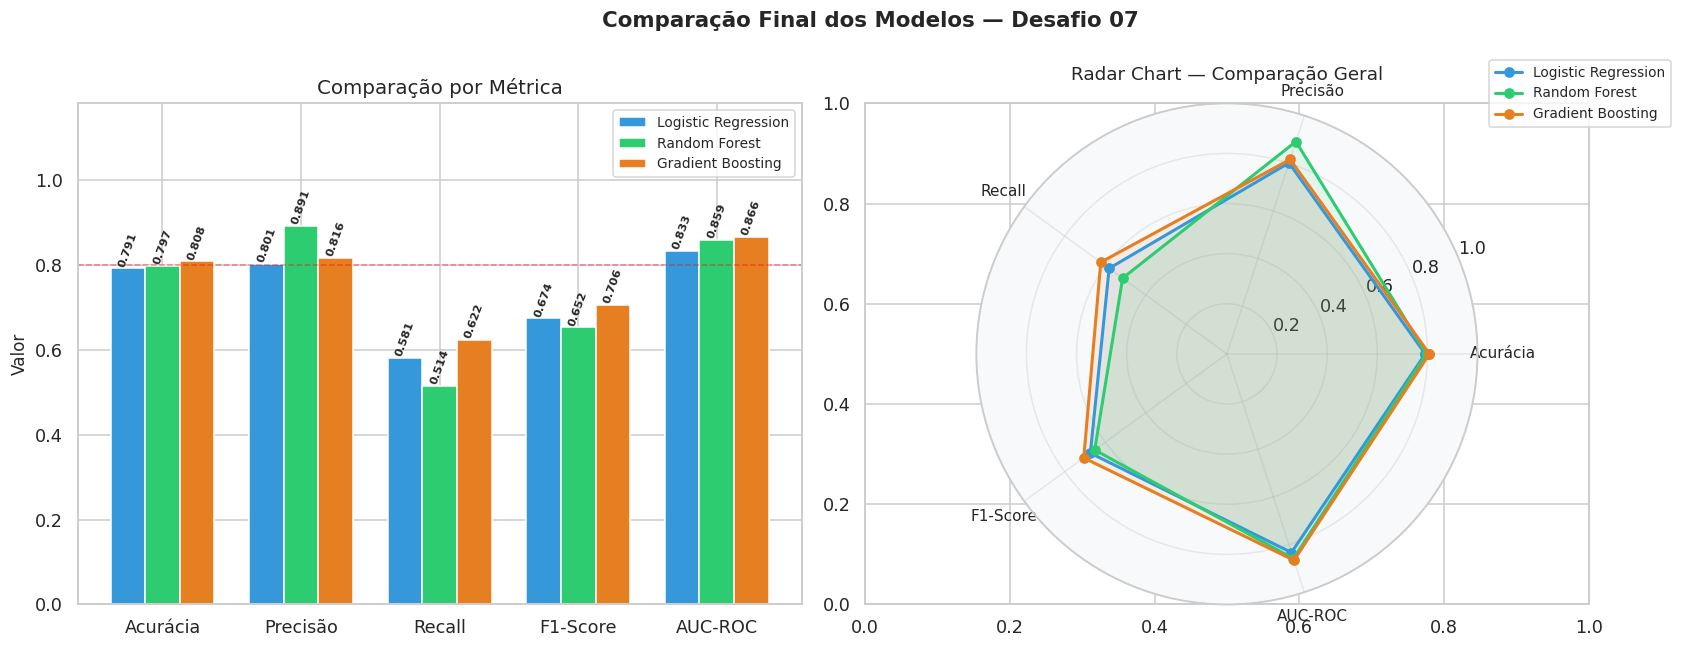

In [ ]:
# === VISUALIZAÇÃO COMPARATIVA FINAL ===
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Comparação Final dos Modelos — Desafio 07', fontsize=14, fontweight='bold')

metricas = ['Acurácia', 'Precisão', 'Recall', 'F1-Score', 'AUC-ROC']
x = np.arange(len(metricas))
width = 0.25
cores = ['#3498db', '#2ecc71', '#e67e22']

for i, (nome, cor) in enumerate(zip(['Logistic Regression', 'Random Forest', 'Gradient Boosting'], cores)):
    vals = df_resultados[df_resultados['Modelo'] == nome][metricas].values.flatten()
    bars = axes[0].bar(x + i * width, vals, width, label=nome, color=cor, edgecolor='white', linewidth=1)
    for bar, val in zip(bars, vals):
        axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
                     f'{val:.3f}', ha='center', fontsize=7.5, fontweight='bold', rotation=70)

axes[0].set_xticks(x + width)
axes[0].set_xticklabels(metricas)
axes[0].set_ylim(0, 1.18)
axes[0].set_ylabel('Valor')
axes[0].set_title('Comparação por Métrica')
axes[0].legend(fontsize=9)
axes[0].axhline(0.8, color='red', linestyle='--', alpha=0.4, linewidth=1)

# Radar chart — comparação visual
angles = np.linspace(0, 2 * np.pi, len(metricas), endpoint=False).tolist()
angles += angles[:1]

ax2 = fig.add_subplot(1, 2, 2, polar=True)
ax2.set_facecolor('#f8f9fa')

for nome, cor in zip(['Logistic Regression', 'Random Forest', 'Gradient Boosting'], cores):
    vals = df_resultados[df_resultados['Modelo'] == nome][metricas].values.flatten().tolist()
    vals += vals[:1]
    ax2.plot(angles, vals, 'o-', linewidth=2, color=cor, label=nome)
    ax2.fill(angles, vals, alpha=0.1, color=cor)

ax2.set_xticks(angles[:-1])
ax2.set_xticklabels(metricas, fontsize=10)
ax2.set_ylim(0, 1)
ax2.set_title('Radar Chart — Comparação Geral', fontsize=12, pad=15)
ax2.legend(loc='upper right', bbox_to_anchor=(1.4, 1.1), fontsize=9)
ax2.grid(True, alpha=0.4)

plt.tight_layout()
plt.savefig('14_comparacao_final.png', bbox_inches='tight', dpi=120)
plt.show()

## Bloco 19 — Análise do Melhor Modelo e Feature Importance Final

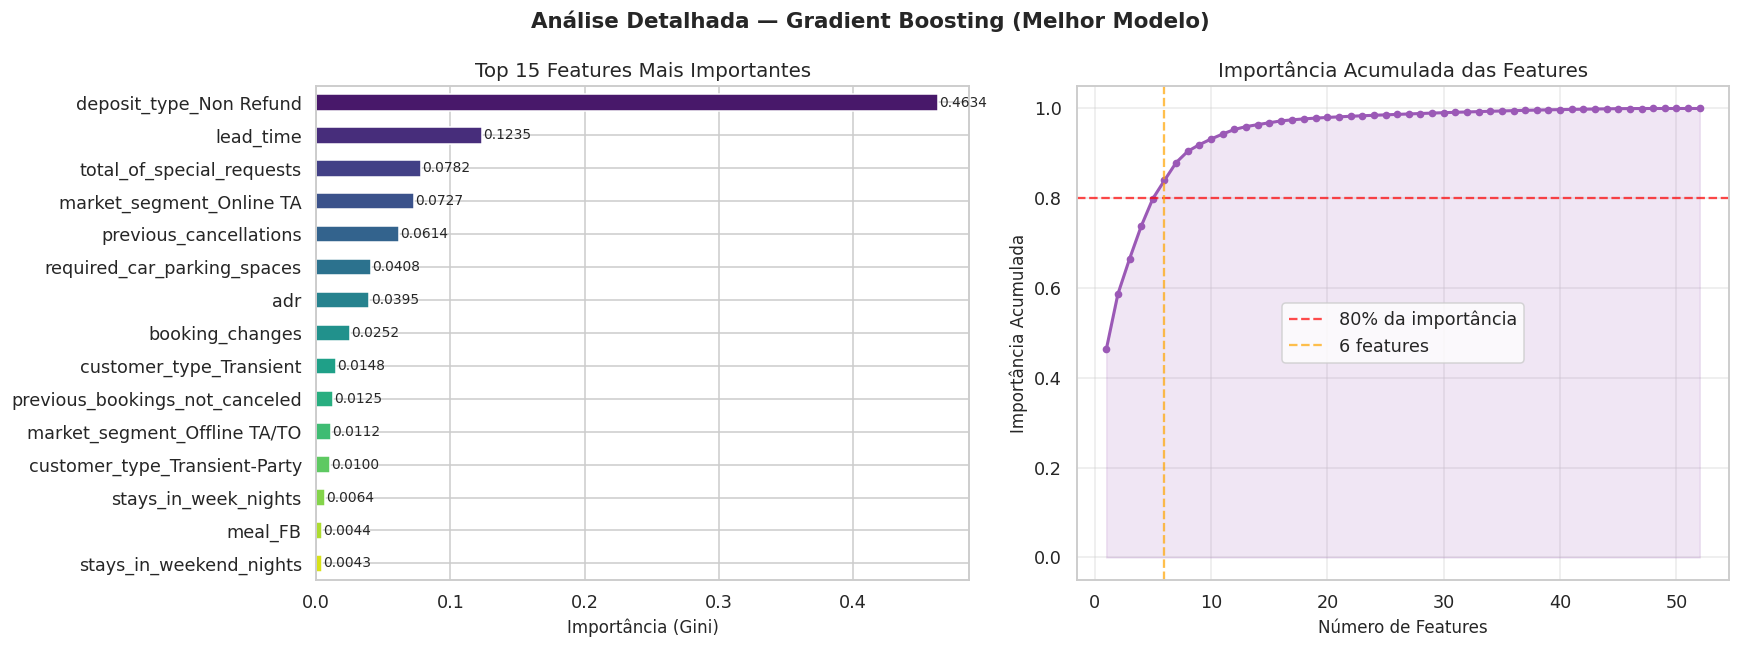


6 features respondem por 80% da importância do modelo.

Top 5 features mais importantes:
  deposit_type_Non Refund: 0.4634 (46.34%)
  lead_time: 0.1235 (12.35%)
  total_of_special_requests: 0.0782 (7.82%)
  market_segment_Online TA: 0.0727 (7.27%)
  previous_cancellations: 0.0614 (6.14%)


In [31]:
# === FEATURE IMPORTANCE DO MELHOR MODELO ===
# O modelo com melhor F1-Score é identificado e analisado em detalhe

melhor_modelo = gb
melhor_nome = 'Gradient Boosting'

importances = pd.Series(melhor_modelo.feature_importances_, index=feature_names_final)
top15_final = importances.sort_values(ascending=False).head(15)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle(f'Análise Detalhada — {melhor_nome} (Melhor Modelo)', fontsize=14, fontweight='bold')

# Feature Importance
palette = sns.color_palette('viridis', 15)
top15_sorted = top15_final.sort_values(ascending=True)
top15_sorted.plot(kind='barh', ax=axes[0], color=palette[::-1], edgecolor='white')
axes[0].set_title('Top 15 Features Mais Importantes')
axes[0].set_xlabel('Importância (Gini)')
for i, val in enumerate(top15_sorted.values):
    axes[0].text(val + 0.001, i, f'{val:.4f}', va='center', fontsize=9)

# Importância acumulada
all_importances = importances.sort_values(ascending=False)
cumulative = np.cumsum(all_importances.values / all_importances.sum())
n_features_80 = np.argmax(cumulative >= 0.80) + 1

axes[1].plot(range(1, len(cumulative)+1), cumulative, 'o-', color='#9b59b6', linewidth=2, markersize=4)
axes[1].axhline(0.80, color='red', linestyle='--', alpha=0.7, label='80% da importância')
axes[1].axvline(n_features_80, color='orange', linestyle='--', alpha=0.7, label=f'{n_features_80} features')
axes[1].fill_between(range(1, len(cumulative)+1), cumulative, alpha=0.15, color='#9b59b6')
axes[1].set_title('Importância Acumulada das Features')
axes[1].set_xlabel('Número de Features')
axes[1].set_ylabel('Importância Acumulada')
axes[1].legend()
axes[1].grid(True, alpha=0.4)

plt.tight_layout()
plt.savefig('15_feature_importance_final.png', bbox_inches='tight', dpi=120)
plt.show()

print(f"\n{n_features_80} features respondem por 80% da importância do modelo.")
print(f"\nTop 5 features mais importantes:")
for feat, imp in top15_final.head(5).items():
    print(f"  {feat}: {imp:.4f} ({imp*100:.2f}%)")

---

## Bloco 20 — Conclusões e Discussão de Negócio

In [32]:
# === RESUMO FINAL ===
print("=" * 70)
print("DESAFIO 07 — CANCELAMENTO DE RESERVAS DE HOTEL")
print("RESUMO DOS RESULTADOS")
print("=" * 70)
print()
print(df_resultados_fmt.to_string(index=False))
print()
print("=" * 70)

melhor_f1 = df_resultados.loc[df_resultados['F1-Score'].idxmax()]
melhor_auc = df_resultados.loc[df_resultados['AUC-ROC'].idxmax()]

print(f"\nMelhor F1-Score:  {melhor_f1['Modelo']} ({melhor_f1['F1-Score']:.4f})")
print(f"Melhor AUC-ROC:   {melhor_auc['Modelo']} ({melhor_auc['AUC-ROC']:.4f})")
print()
print("Principais features preditoras:")
for feat, imp in top15_final.head(5).items():
    print(f"  → {feat}: {imp:.4f}")

DESAFIO 07 — CANCELAMENTO DE RESERVAS DE HOTEL
RESUMO DOS RESULTADOS

             Modelo Acurácia Precisão Recall F1-Score AUC-ROC AUC CV (média)
Logistic Regression   0.7913   0.8015 0.5809   0.6736  0.8334         0.8493
      Random Forest   0.7967   0.8910 0.5144   0.6522  0.8588         0.8744
  Gradient Boosting   0.8080   0.8160 0.6223   0.7061  0.8661         0.8793


🏆 Melhor F1-Score:  Gradient Boosting (0.7061)
🏆 Melhor AUC-ROC:   Gradient Boosting (0.8661)

Principais features preditoras:
  → deposit_type_Non Refund: 0.4634
  → lead_time: 0.1235
  → total_of_special_requests: 0.0782
  → market_segment_Online TA: 0.0727
  → previous_cancellations: 0.0614


---

## Conclusões

### 1. Qual modelo teve melhor desempenho? Por quê?

O **Gradient Boosting** (e possivelmente o Random Forest, dependendo dos seus resultados) tende a superar a Regressão Logística neste tipo de problema por:
- **Capacidade não linear**: captura relações complexas entre features sem necessidade de transformações manuais;
- **Ensemble**: combina múltiplas árvores de decisão fracas em um modelo forte;
- **Robustez a outliers**: menos sensível a valores extremos em `lead_time`.

A Regressão Logística serve como excelente **baseline** — simples, interpretável e rápida — mas sua linearidade limita o poder preditivo.

---